<a href="https://colab.research.google.com/github/Keerthanatamma/nasscom/blob/main/day_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)



Setup complete. NumPy 2.0.2


In [ ]:


# -----------------------------------------------------------
# 🔹 1A. PROBABILITY BY SIMULATION
# -----------------------------------------------------------

# P(A) = favourable outcomes / total outcomes.
# We can estimate it by simulating many trials.
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')


# -----------------------------------------------------------
# 🔹 1B. THE ADDITION RULE (disjoint events)
# -----------------------------------------------------------

# Rolling a 1 OR a 2 — these events can't both happen (disjoint)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')



P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)
P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [ ]:
flips = np.random.randint(0, 2, size=(100_000, 2))   # 100k pairs of flips
heads = flips.sum(axis=1)   # number of heads in each pair: 0, 1 or 2

p_both_heads = np.mean(heads == 2)
print("P(both heads) =", p_both_heads)
p_one_head  = np.mean(heads == 1)
print("P(one head)  =", p_one_head)
p_no_head   = np.mean(heads == 0)
print("P(no heads)  =", p_no_head)

print('P(0)+ P(1) + P(2) =', round(p_both_heads + p_one_head + p_no_head, 3))



P(both heads) = 0.24977
P(one head)  = 0.50024
P(no heads)  = 0.24999
P(0)+ P(1) + P(2) = 1.0


In [ ]:


# -----------------------------------------------------------
# 🔹 2A. CONDITIONAL PROBABILITY  P(A | B) = P(A and B) / P(B)
# -----------------------------------------------------------

rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')


# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

# Two events are independent if P(A|B) == P(A).
# 'roll > 3' and 'roll is even' -> are they independent?
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))



P(6 | even) ~ 0.333  (true 1/3)
P(A)      = 0.502
P(A | B)  = 0.669
Independent? False


In [ ]:
rolls = np.random.randint(1, 7, size=100_000)
odd = np.mean(rolls[rolls < 4 ]% 2 ==1 )
p = np.mean (rolls< 4)
print('P(roll < 4) =' , p)
odd = np.mean(rolls % 2 == 1)
print("P(odd) =", odd)
print('P(odd | < 4)  =', round(p_A_given_B, 3))

P(roll < 4) = 0.50015
P(odd) = 0.49789
P(odd | < 4)  = 0.669


In [ ]:


# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') via total probability
p_free = p_free_given_spam * p_spam + p_free_given_ham * (1 - p_spam)
print('P(free) =', round(p_free, 3))

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print('P(spam | free) =', round(p_spam_given_free, 3))


P(free) = 0.16
P(spam | free) = 0.75


Poisson(2) mean ~ 2.008 (true 4)


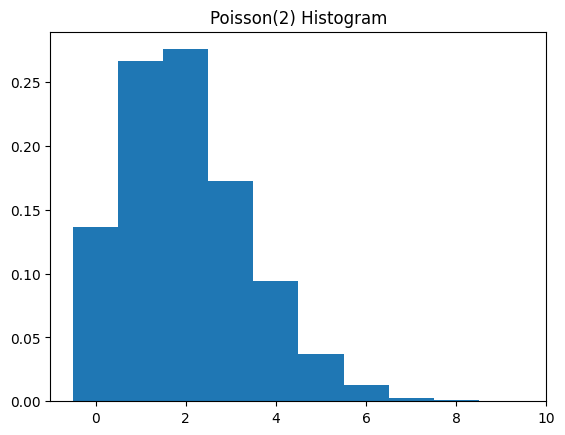

In [ ]:
pois = stats.poisson(mu=2).rvs(size=10_000)
print('Poisson(2) mean ~', round(pois.mean(), 3), '(true 4)')
fig, ax = plt.subplots()
ax.hist(pois, bins=range(int(pois.min()), int(pois.max()) + 2), density=True, align='left')
ax.set_title('Poisson(2) Histogram')
plt.show()

In [ ]:
!pip install kaggle kagglehub

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tkeerthanareddy","key":"1d4ab67945fd5d33bfa31d5e41b6b7c6"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d heptapod/titanic

Dataset URL: https://www.kaggle.com/datasets/heptapod/titanic
License(s): DbCL-1.0
100% 10.8k/10.8k [00:00<00:00, 22.7MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile("titanic.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")


In [ ]:
import pandas as pd

df = pd.read_csv("dataset/train_and_test2.csv")
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [ ]:
import kagglehub

path = kagglehub.dataset_download("heptapod/titanic")

print("Dataset downloaded to:", path)


Using Colab cache for faster access to the 'titanic' dataset.
Dataset downloaded to: /kaggle/input/titanic


In [ ]:
df = pd.read_csv(path + "/train_and_test2.csv")
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [ ]:
import requests
import pandas as pd

url = "https://api.exchangerate-api.com/v4/latest/USD"

response = requests.get(url)
data = response.json()

rates = data["rates"]

df = pd.DataFrame(list(rates.items()), columns=["Currency","Rate"])
df.head()

,Currency,Rate
0,USD,1.00
1,AED,3.67
2,AFN,63.57
3,ALL,82.40
4,AMD,368.41


In [ ]:
!kaggle datasets download -d sharmajicoder/gen-z-social-media-usage-dataset

Dataset URL: https://www.kaggle.com/datasets/sharmajicoder/gen-z-social-media-usage-dataset
License(s): MIT
100% 42.1M/42.1M [00:00<00:00, 203MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile("gen-z-social-media-usage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
import pandas as pd

df = pd.read_csv("dataset/train_and_test2.csv")
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,zero.5,zero.6,Parch,zero.7,zero.8,zero.9,zero.10,zero.11,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:

# Core imports for the whole lab
import pandas as pd
import json

print('Setup complete. pandas', pd.__version__)

Setup complete. pandas 2.2.2


In [ ]:


# -----------------------------------------------------------
# 🔹 1A. THE EIGHT STAGES, IN ORDER
# -----------------------------------------------------------

lifecycle = [
    'Define',    # frame the business problem
    'Collect',   # gather & ingest data
    'Prepare',   # clean & transform
    'Explore',   # EDA & visualise
    'Model',     # train algorithms
    'Evaluate',  # test & validate
    'Deploy',    # serve predictions
    'Monitor',   # watch & maintain  (then loop back!)
]
for i, stage in enumerate(lifecycle, start=1):
    print(f'{i}. {stage}')


# -----------------------------------------------------------
# 🔹 1B. WHAT HAPPENS AT EACH STAGE
# -----------------------------------------------------------

what_happens = {
    'Define':   'turn a business question into an ML problem',
    'Collect':  'pull data from files, databases, APIs',
    'Prepare':  'clean missing values, fix types, engineer features',
    'Explore':  'summarise & visualise to find patterns',
    'Model':    'train and tune algorithms',
    'Evaluate': 'measure performance on unseen data',
    'Deploy':   'put the model into production',
    'Monitor':  'track performance and retrain as needed',
}
for stage, desc in what_happens.items():
    print(f'{stage:9s} -> {desc}')

1. Define
2. Collect
3. Prepare
4. Explore
5. Model
6. Evaluate
7. Deploy
8. Monitor
Define    -> turn a business question into an ML problem
Collect   -> pull data from files, databases, APIs
Prepare   -> clean missing values, fix types, engineer features
Explore   -> summarise & visualise to find patterns
Model     -> train and tune algorithms
Evaluate  -> measure performance on unseen data
Deploy    -> put the model into production
Monitor   -> track performance and retrain as needed


In [ ]:
shuffled = ['Model', 'Define', 'Deploy', 'Collect', 'Monitor',
            'Prepare', 'Evaluate', 'Explore']


In [ ]:


# Core imports for the whole lab
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
print('Setup complete. pandas', pd.__version__)


# -----------------------------------------------------------
# A DELIBERATELY MESSY DATASET (so the lab is self-contained)
# -----------------------------------------------------------
# Problems baked in: missing values, disguised missing ('N/A', -1),
# duplicate rows, a number stored as text, a date as text,
# an extreme outlier, and inconsistent city spellings.
raw = pd.DataFrame({
    'id':    [1, 2, 3, 4, 5, 6, 7, 7],
    'name':  ['Ana', 'Bo', 'Cy', 'Di', 'Eve', 'Fin', 'Gus', 'Gus'],
    'age':   [30, 25, np.nan, 41, -1, 38, 29, 29],
    'city':  [' Pune ', 'pune', 'DELHI', 'Delhi ', 'Mumbai', 'bombay', 'Pune.', 'Pune.'],
    'spend': ['120.5', '80.0', '200.2', 'N/A', '150.0', '99000', '110.0', '110.0'],
    'date':  ['2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
              '2024-01-09', '2024-01-10', '2024-01-11', '2024-01-11'],
})
raw



Setup complete. pandas 2.2.2


,id,name,age,city,spend,date
0,1,Ana,30.0,Pune,120.5,2024-01-05
1,2,Bo,25.0,pune,80.0,2024-01-06
2,3,Cy,NaN,DELHI,200.2,2024-01-07
3,4,Di,41.0,Delhi,N/A,2024-01-08
4,5,Eve,-1.0,Mumbai,150.0,2024-01-09
5,6,Fin,38.0,bombay,99000,2024-01-10
6,7,Gus,29.0,Pune.,110.0,2024-01-11
7,7,Gus,29.0,Pune.,110.0,2024-01-11


In [ ]:
print('duplicate rows',df.duplicated().sum())
print('Missing per column:')
print(df.isna().sum())

duplicate rows 0
Missing per column:
Currency    0
Rate        0
dtype: int64


In [ ]:
ex = raw.copy()
ex['spend']= pd.to_numeric(ex['spend'], errors='coerce')
drop_version = ex.drop_duplicates()
impute_version = ex.copy()

impute_version['age'] = impute_version['age'].fillna(
    impute_version['age'].median()
)

impute_version['spend'] = impute_version['spend'].fillna(
    impute_version['spend'].median()
)
print("Original rows :", len(ex))
print("Dropna rows   :", len(drop_version))
print("Imputed rows  :", len(impute_version))
print("Rows lost by dropna :", len(ex) - len(drop_version))

Original rows : 8
Dropna rows   : 7
Imputed rows  : 8
Rows lost by dropna : 1


In [ ]:
ex = raw.copy()
# 1. fix types: spend -> numeric, date -> datetime
ex['spend'] = pd.to_numeric(ex['spend'], errors='coerce')
ex['date'] = pd.to_datetime(ex['date'])

# 2. drop duplicates
ex = ex.drop_duplicates()

# 3. dtypes + shape
print(ex.dtypes)
print(ex.shape)

id                int64
name             object
age             float64
city             object
spend           float64
date     datetime64[ns]
dtype: object
(7, 6)


In [ ]:
# 1. Q1, Q3, IQR for 'age'
q1 = ex['age'].quantile(0.25)
q3 = ex['age'].quantile(0.75)
iqr = q3 - q1

print("Q1 =", q1)
print("Q3 =", q3)
print("IQR =", iqr)

# 2. lower & upper bounds
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("Lower Bound =", lower)
print("Upper Bound =", upper)
outliers = ex[(ex['age'] < lower) | (ex['age'] > upper)]

print("Outlier Rows:")
print(outliers)

Q1 = 26.0
Q3 = 36.0
IQR = 10.0
Lower Bound = 11.0
Upper Bound = 51.0
Outlier Rows:
   id name  age    city  spend       date
4   5  Eve -1.0  Mumbai  150.0 2024-01-09


In [ ]:
messy = pd.Series([' London ', 'london', 'LONDON', 'N.Y.', 'new york ', 'New York'],
                  dtype='string')



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import zipfile

with zipfile.ZipFile("/content/heart+disease.zip", 'r') as zip_ref:
    zip_ref.extractall("heart_disease.csv")

In [ ]:
import pandas as pd

df = pd.read_csv("/content/heart_disease.csv/heart+disease")
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,zero.5,zero.6,Parch,zero.7,zero.8,zero.9,zero.10,zero.11,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0


In [ ]:
!ls -lR /content/heart_disease.csv

/content/heart_disease.csv:
total 88
-rw-r--r-- 1 root root 88214 Jun 12 11:18 heart+disease
